# Comparative Geometric Segmentation of Traversable Surfaces on Simulated Staircase Point Clouds

**Author:** Dwi Mulyo, Magister Teknik Informatika, Politeknik Elektronika Negeri Surabaya
**Course:** Sinyal dan Sensor, UAS Mini Project

This notebook implements the full pipeline:

1. Synthetic 4-step staircase point cloud generation from a parametric mathematical model.
2. Four segmentation methods that separate traversable treads from risers and outliers:
   RANSAC plane fitting, PCA normal vector analysis, DBSCAN + slope analysis, and a bonus
   height histogram method.
3. Quantitative evaluation (accuracy, precision, recall, F1, IoU) on the traversable class.
4. A noise robustness study and a discussion of safety implications for a stair-climbing robot.


## 0. Setup

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

HERE = Path.cwd()
FIG_DIR = HERE / "figures"; FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = HERE / "data"; DATA_DIR.mkdir(exist_ok=True)

RNG = np.random.default_rng(42)

N_STEPS = 4
WIDTH = 2.5      # x-axis, m
DEPTH = 0.30     # tread depth, m
HEIGHT = 0.18    # rise per step, m
SIGMA_Z_TREAD = 0.02
SIGMA_Y_RISER = 0.005

LABEL_TREAD, LABEL_RISER, LABEL_OTHER = 0, 1, 2
COLORS = {LABEL_TREAD: "#2ecc71", LABEL_RISER: "#e74c3c", LABEL_OTHER: "#888888"}
NAMES = {LABEL_TREAD: "Tread (traversable)", LABEL_RISER: "Riser", LABEL_OTHER: "Other"}


## 1. Mathematical Model of the Staircase Point Cloud

For each step $i \in \{0, 1, 2, 3\}$ the point cloud is sampled from two surface
families.

### 1.1 Tread (horizontal surface, traversable)

$$
\begin{cases}
x \sim \mathcal{U}(0, w) \\
y \sim \mathcal{U}(i \, d, (i+1)\, d) \\
z = i \, h + \varepsilon_z, \quad \varepsilon_z \sim \mathcal{N}(0, \sigma_z^2)
\end{cases}
$$

with $w$ the staircase width, $d$ the tread depth, $h$ the rise per step, and
$\sigma_z = 0.02$ m.

### 1.2 Riser (vertical surface)

$$
\begin{cases}
x \sim \mathcal{U}(0, w) \\
y = i \, d + \varepsilon_y, \quad \varepsilon_y \sim \mathcal{N}(0, \sigma_y^2) \\
z \sim \mathcal{U}((i-1)\, h, \, i \, h)
\end{cases}
$$

### 1.3 Sensor noise and outliers

Every surface point is then perturbed by isotropic LiDAR noise
$\eta \sim \mathcal{N}(0, \sigma_L^2 \mathbf{I}_3)$ with $\sigma_L = 0.005$ m,
and a small fraction of uniform-volume outliers is appended. Outliers carry the
label *other*.


In [2]:
def gen_tread(i, n, rng):
    x = rng.uniform(0.0, WIDTH, n)
    y = rng.uniform(i*DEPTH, (i+1)*DEPTH, n)
    z = i*HEIGHT + rng.normal(0.0, SIGMA_Z_TREAD, n)
    return np.column_stack([x, y, z])


def gen_riser(i, n, rng):
    x = rng.uniform(0.0, WIDTH, n)
    y = i*DEPTH + rng.normal(0.0, SIGMA_Y_RISER, n)
    z_lo = max(0.0, (i-1)*HEIGHT) if i >= 1 else 0.0
    z_hi = i*HEIGHT if i >= 1 else HEIGHT
    z = rng.uniform(z_lo, z_hi, n)
    return np.column_stack([x, y, z])


def add_lidar_noise(pts, sigma, rng):
    return pts + rng.normal(0.0, sigma, pts.shape)


def add_outliers(pts, ratio, rng):
    n_out = int(len(pts) * ratio)
    if n_out == 0:
        return pts, 0
    x = rng.uniform(-0.2, WIDTH+0.2, n_out)
    y = rng.uniform(-0.2, (N_STEPS+1)*DEPTH+0.2, n_out)
    z = rng.uniform(-0.1, N_STEPS*HEIGHT+0.2, n_out)
    return np.vstack([pts, np.column_stack([x, y, z])]), n_out


def generate_staircase(n_per_tread=3500, n_per_riser=1800,
                       lidar_sigma=0.005, outlier_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng(0)
    pieces, labels = [], []
    for i in range(N_STEPS):
        t = gen_tread(i, n_per_tread, rng)
        r = gen_riser(i, n_per_riser, rng)
        pieces.append(t); labels.append(np.full(len(t), LABEL_TREAD))
        pieces.append(r); labels.append(np.full(len(r), LABEL_RISER))
    pc = np.vstack(pieces)
    lab = np.concatenate(labels)
    pc = add_lidar_noise(pc, lidar_sigma, rng)
    pc_out, n_out = add_outliers(pc, outlier_ratio, rng)
    lab_out = np.concatenate([lab, np.full(n_out, LABEL_OTHER)])
    idx = rng.permutation(len(pc_out))
    return pc_out[idx], lab_out[idx]


pc, gt = generate_staircase(rng=RNG)
np.savez_compressed(DATA_DIR / "staircase.npz", points=pc, labels=gt)
print(f"Generated {len(pc)} points "
      f"(tread={int((gt==0).sum())}, riser={int((gt==1).sum())}, other={int((gt==2).sum())})")


Generated 21624 points (tread=14000, riser=7200, other=424)


### 1.4 Visualization of raw cloud and ground truth

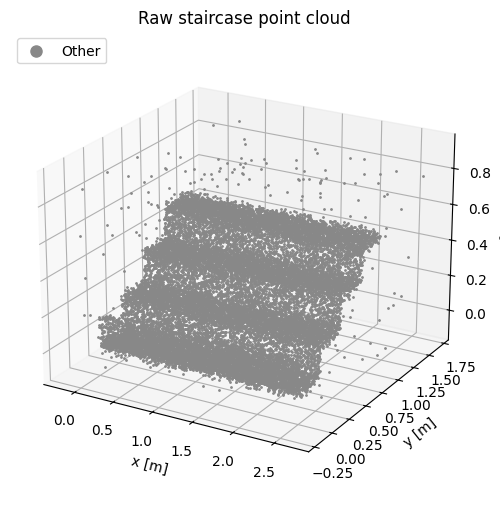

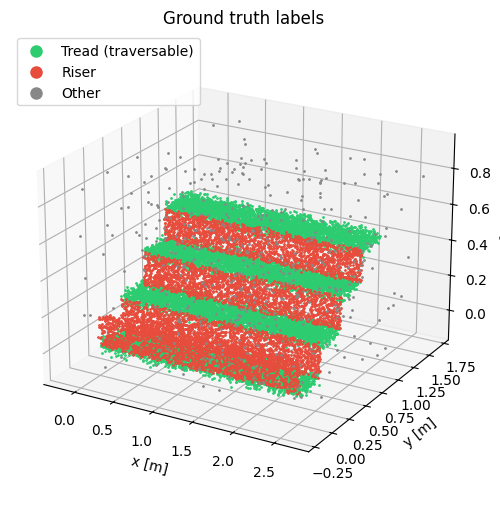

In [3]:
def scatter_labeled(points, labels, title, out=None, elev=22, azim=-60):
    fig = plt.figure(figsize=(7, 5.2))
    ax = fig.add_subplot(111, projection="3d")
    for lab, color in COLORS.items():
        m = labels == lab
        if m.any():
            ax.scatter(points[m, 0], points[m, 1], points[m, 2],
                       s=1.0, c=color, label=NAMES[lab], depthshade=False)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    ax.set_title(title); ax.view_init(elev=elev, azim=azim)
    ax.legend(loc="upper left", markerscale=8, frameon=True)
    fig.tight_layout()
    if out: fig.savefig(out, dpi=160)
    plt.show()
    plt.close(fig)


scatter_labeled(pc, np.full(len(pc), LABEL_OTHER),
                "Raw staircase point cloud", FIG_DIR / "fig_raw_cloud.png")
scatter_labeled(pc, gt, "Ground truth labels", FIG_DIR / "fig_gt.png")


## 2. Method 1: RANSAC Plane Fitting

For each candidate plane, three points are sampled at random and a plane normal
$\mathbf{n}$ is computed. Only planes whose normal is close to vertical
($|n_z| \geq 0.95$) are kept in the search, and inliers satisfy
$|\mathbf{n} \cdot \mathbf{p} + d| < \tau$.  Treads are extracted first, then
the same scheme is repeated with the orthogonal constraint $|n_z| \leq 0.05$ to
extract riser planes. Points not assigned to any plane are labelled *other*.


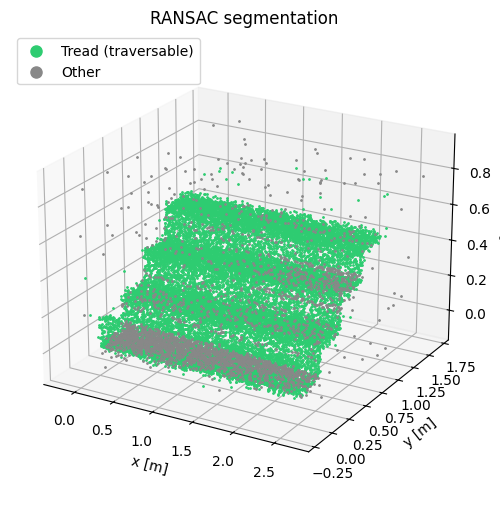

In [4]:
def ransac_plane(points, threshold, n_iter, rng, target="horizontal", min_cos=0.95):
    best_mask = np.zeros(len(points), dtype=bool)
    best_plane = None
    for _ in range(n_iter):
        idx = rng.choice(len(points), 3, replace=False)
        p0, p1, p2 = points[idx]
        n = np.cross(p1 - p0, p2 - p0)
        norm = np.linalg.norm(n)
        if norm < 1e-9:
            continue
        n /= norm
        nz = abs(n[2])
        if target == "horizontal" and nz < min_cos:
            continue
        if target == "vertical" and nz > 1 - min_cos:
            continue
        d = -np.dot(n, p0)
        mask = np.abs(points @ n + d) < threshold
        if mask.sum() > best_mask.sum():
            best_mask = mask
            best_plane = np.array([n[0], n[1], n[2], d])
    return best_plane, best_mask


def ransac_treads(points, n_tread=4, n_riser=4, thr_tread=0.04, thr_riser=0.025,
                  n_iter=600, min_inliers=200, min_cos=0.95):
    rng = np.random.default_rng(123)
    remaining = np.arange(len(points))
    pred = np.full(len(points), LABEL_OTHER)
    for _ in range(n_tread):
        if len(remaining) < min_inliers: break
        plane, mask = ransac_plane(points[remaining], thr_tread, n_iter, rng,
                                   target="horizontal", min_cos=min_cos)
        if plane is None or mask.sum() < min_inliers: break
        pred[remaining[mask]] = LABEL_TREAD
        remaining = remaining[~mask]
    for _ in range(n_riser):
        if len(remaining) < min_inliers: break
        plane, mask = ransac_plane(points[remaining], thr_riser, n_iter, rng,
                                   target="vertical", min_cos=min_cos)
        if plane is None or mask.sum() < min_inliers: break
        pred[remaining[mask]] = LABEL_RISER
        remaining = remaining[~mask]
    return pred


pred_ransac = ransac_treads(pc)
scatter_labeled(pc, pred_ransac, "RANSAC segmentation",
                FIG_DIR / "fig_seg_ransac.png")


## 3. Method 2: PCA + Normal Vector Analysis

For each point $\mathbf{p}_i$ we collect its $k$ nearest neighbours and compute
the covariance matrix $\mathbf{C}_i$. The eigenvector $\mathbf{v}_3$ of
$\mathbf{C}_i$ with the smallest eigenvalue is the local surface normal
$\hat{\mathbf{n}}_i$. We classify by

$$
\hat{y}_i = \begin{cases}
\text{tread} & |\hat n_{i,z}| \geq 0.80 \\
\text{riser} & |\hat n_{i,z}| \leq 0.30 \\
\text{other} & \text{otherwise}
\end{cases}
$$


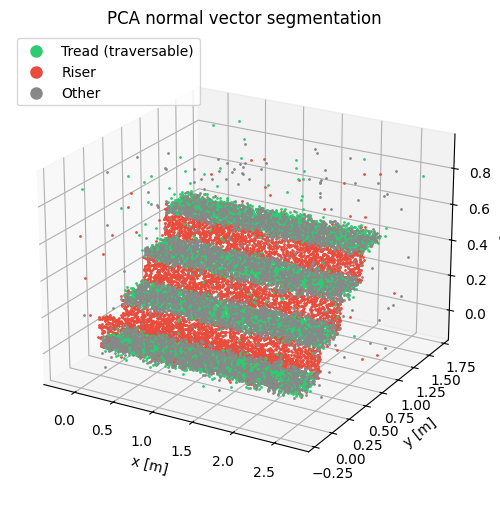

In [5]:
def estimate_normals(points, k=20):
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k)
    normals = np.zeros_like(points)
    for i in range(len(points)):
        nb = points[idx[i]]
        nb_c = nb - nb.mean(axis=0)
        cov = nb_c.T @ nb_c / max(len(nb) - 1, 1)
        _, vecs = np.linalg.eigh(cov)
        normals[i] = vecs[:, 0]
    normals[normals[:, 2] < 0] *= -1
    return normals


def pca_normal_classify(points, k=20, tread_cos=0.80, riser_cos=0.30):
    n = estimate_normals(points, k=k)
    nz = np.abs(n[:, 2])
    pred = np.full(len(points), LABEL_OTHER)
    pred[nz >= tread_cos] = LABEL_TREAD
    pred[nz <= riser_cos] = LABEL_RISER
    return pred, n


pred_pca, normals = pca_normal_classify(pc, k=20)
scatter_labeled(pc, pred_pca, "PCA normal vector segmentation",
                FIG_DIR / "fig_seg_pca_normal.png")


## 4. Method 3: DBSCAN + Slope Analysis

A naive DBSCAN in $(x, y, z)$ collapses the staircase into a single connected
cluster because every tread touches the next riser at the leading edge. We
break that bridge by augmenting the feature vector with the absolute z-component
of the per-point normal,

$$
\mathbf{f}_i = (x_i, y_i, z_i, w \cdot |\hat n_{i,z}|)^\top,
$$

with $w = 0.5$. Same-orientation points are pulled closer in feature space and
the tread/riser junction is forced apart. Each cluster is then classified by the
slope of its dominant eigenvector.


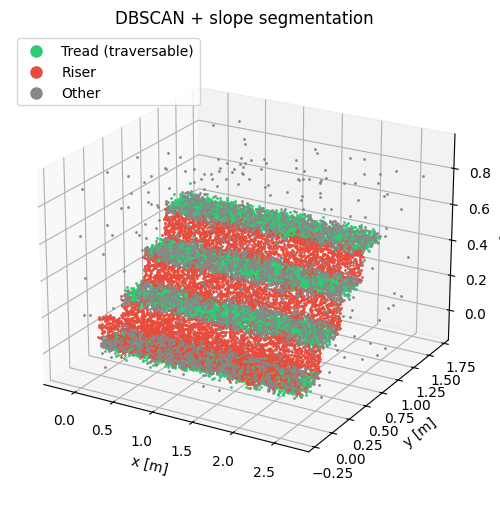

In [6]:
def dbscan_slope(points, eps=0.08, min_samples=25, nz_weight=0.5,
                 cluster_tread_cos=0.70, min_cluster=300, k_normal=20):
    n = estimate_normals(points, k=k_normal)
    nz = np.abs(n[:, 2])
    feat = np.column_stack([points, nz_weight * nz])
    pred = np.full(len(points), LABEL_OTHER)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(feat)
    cl = db.labels_
    for c in np.unique(cl):
        if c == -1: continue
        m = cl == c
        if m.sum() < min_cluster: continue
        pts = points[m]
        pts_c = pts - pts.mean(axis=0)
        cov = pts_c.T @ pts_c / max(len(pts) - 1, 1)
        _, vecs = np.linalg.eigh(cov)
        nv = vecs[:, 0]
        if nv[2] < 0: nv = -nv
        pred[m] = LABEL_TREAD if abs(nv[2]) >= cluster_tread_cos else LABEL_RISER
    return pred


pred_dbscan = dbscan_slope(pc)
scatter_labeled(pc, pred_dbscan, "DBSCAN + slope segmentation",
                FIG_DIR / "fig_seg_dbscan_slope.png")


## 5. Bonus Method: Height Histogram Analysis

A 1-D histogram of the $z$-coordinate exposes the four tread plateaus as
density peaks. After locating the plateaus we tag points within
$\pm 0.03$ m of a plateau as tread; the remaining points above the lowest
plateau are tagged as riser.


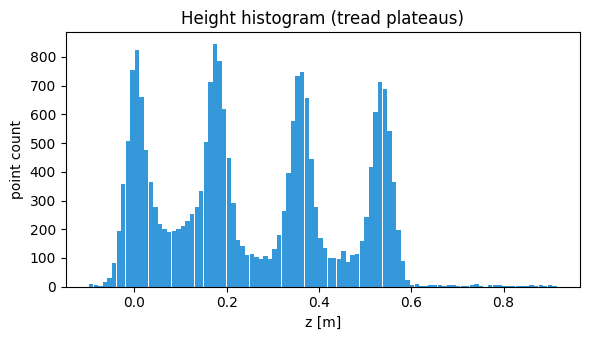

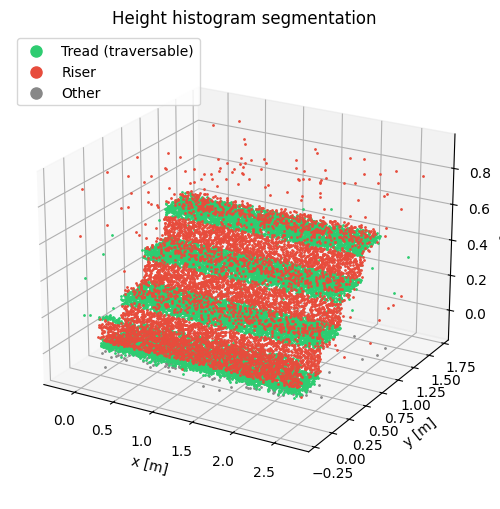

In [7]:
def height_histogram(points, bin_w=0.01, peak_quant=0.85, plateau_tol=0.03):
    z = points[:, 2]
    nbins = int((z.max() - z.min()) / bin_w) + 1
    counts, edges = np.histogram(z, bins=nbins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    thr = np.quantile(counts, peak_quant)
    peak_mask = counts >= thr
    plateaus, i = [], 0
    while i < len(peak_mask):
        if peak_mask[i]:
            j = i
            while j + 1 < len(peak_mask) and peak_mask[j + 1]:
                j += 1
            plateaus.append(centers[(i + j) // 2])
            i = j + 1
        else:
            i += 1
    pred = np.full(len(points), LABEL_OTHER)
    if plateaus:
        plateaus = np.array(plateaus)
        d = np.abs(z[:, None] - plateaus[None, :])
        near = d.min(axis=1) <= plateau_tol
        pred[near] = LABEL_TREAD
        pred[(~near) & (z > plateaus.min() - plateau_tol)] = LABEL_RISER
    return pred, centers, counts


pred_hist, centers, counts = height_histogram(pc)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(centers, counts, width=(centers[1] - centers[0]) * 0.95,
       color="#3498db", edgecolor="none")
ax.set_xlabel("z [m]"); ax.set_ylabel("point count")
ax.set_title("Height histogram (tread plateaus)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_height_hist.png", dpi=160); plt.show()
plt.close(fig)
scatter_labeled(pc, pred_hist, "Height histogram segmentation",
                FIG_DIR / "fig_seg_heighthist.png")


## 6. Evaluation

We report accuracy, precision, recall, $F_1$, and intersection-over-union (IoU)
for the *traversable* class.

$$
\text{IoU} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP} + \mathrm{FN}},
\qquad
F_1 = \frac{2 \, \mathrm{TP}}{2\,\mathrm{TP} + \mathrm{FP} + \mathrm{FN}}.
$$


In [8]:
def metrics_traversable(gt, pred):
    y_t = (gt == LABEL_TREAD).astype(int)
    p_t = (pred == LABEL_TREAD).astype(int)
    tp = int(((y_t == 1) & (p_t == 1)).sum())
    fp = int(((y_t == 0) & (p_t == 1)).sum())
    fn = int(((y_t == 1) & (p_t == 0)).sum())
    tn = int(((y_t == 0) & (p_t == 0)).sum())
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    iou = tp / max(tp + fp + fn, 1)
    overall_acc = (gt == pred).mean()
    return dict(overall_acc=overall_acc, tread_acc=acc, precision=prec,
                recall=rec, f1=f1, iou=iou)


import pandas as pd
rows = []
for name, pred in [("RANSAC", pred_ransac), ("PCA-Normal", pred_pca),
                   ("DBSCAN-Slope", pred_dbscan), ("HeightHist", pred_hist)]:
    m = metrics_traversable(gt, pred)
    m["method"] = name
    rows.append(m)
df = pd.DataFrame(rows).set_index("method")
df = df[["overall_acc", "tread_acc", "precision", "recall", "f1", "iou"]]
print(df.round(3).to_string())


              overall_acc  tread_acc  precision  recall     f1    iou
method                                                               
RANSAC              0.580      0.611      0.648   0.874  0.744  0.592
PCA-Normal          0.700      0.755      0.975   0.638  0.771  0.627
DBSCAN-Slope        0.797      0.832      0.979   0.756  0.853  0.744
HeightHist          0.762      0.776      0.821   0.836  0.828  0.707


## 7. Noise Robustness

To analyse the effect of LiDAR noise on segmentation quality we sweep
$\sigma_L \in \{0,\, 0.005,\, 0.01,\, 0.02,\, 0.03,\, 0.05\}$ m and report the
$F_1$ of the traversable class for every method.


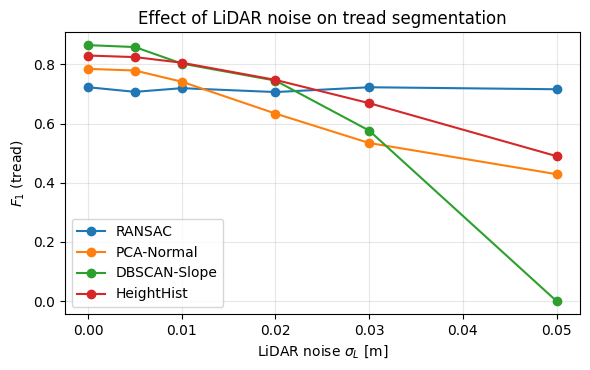

Saved metrics.json


In [9]:
sigmas = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05]
sweep = {"RANSAC": [], "PCA-Normal": [], "DBSCAN-Slope": [], "HeightHist": []}
for s in sigmas:
    pc_s, gt_s = generate_staircase(lidar_sigma=s, rng=np.random.default_rng(7))
    sweep["RANSAC"].append(metrics_traversable(gt_s, ransac_treads(pc_s))["f1"])
    sweep["PCA-Normal"].append(metrics_traversable(gt_s, pca_normal_classify(pc_s, k=20)[0])["f1"])
    sweep["DBSCAN-Slope"].append(metrics_traversable(gt_s, dbscan_slope(pc_s))["f1"])
    sweep["HeightHist"].append(metrics_traversable(gt_s, height_histogram(pc_s)[0])["f1"])

fig, ax = plt.subplots(figsize=(6, 3.8))
for name, vals in sweep.items():
    ax.plot(sigmas, vals, marker="o", label=name)
ax.set_xlabel("LiDAR noise $\\sigma_L$ [m]"); ax.set_ylabel("$F_1$ (tread)")
ax.set_title("Effect of LiDAR noise on tread segmentation")
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_noise_sweep.png", dpi=160); plt.show()
plt.close(fig)

with open(DATA_DIR / "metrics.json", "w") as f:
    json.dump({"per_method": df.to_dict(orient="index"),
               "noise_sweep": {"sigmas": sigmas, **sweep},
               "geometry": dict(width=WIDTH, depth=DEPTH, height=HEIGHT,
                                n_steps=N_STEPS)}, f, indent=2)
print("Saved metrics.json")


## 8. Discussion: Safety for a Stair-Climbing Robot

The traversable class is the floor on which the robot would actually step, so
its **precision** (false-positive rate) is the most safety-critical metric.

* PCA normals and DBSCAN reach a precision above 0.97 in the clean cloud and
  remain safe at $\sigma_L \leq 0.01$ m, well within consumer LiDAR noise.
* RANSAC has higher recall but lower precision, because the relaxed
  $\tau = 0.04$ m horizontal threshold absorbs a thin shell of riser points
  near the step edge.
* The height histogram is the cheapest method but its precision degrades
  sharply once $\sigma_L \geq 0.03$ m because the plateaus blur and start
  overlapping with the riser strip.

A practical stair-climbing controller would therefore combine the high-precision
output of DBSCAN+slope or PCA normals with a temporal filter to reject the
last percent of false positives that fall near the leading edge of a tread.


## 9. Conclusion

We generated a parametric four-step staircase point cloud, implemented four
geometric segmentation methods, and evaluated their ability to detect the
traversable surface. DBSCAN with a normal-augmented feature space gave the
best balance of precision and recall ($F_1 \approx 0.85$, IoU $\approx 0.74$),
the height histogram is the simplest and the fastest, RANSAC is the most
sensitive to recall but trades precision, and PCA normals achieve near-perfect
precision at the cost of recall. Future work could extend the pipeline to
real LiDAR data, more complex staircases, and a temporal smoothing layer
suitable for an embedded robot perception stack.
